In [1]:
# ============================================================
# LSTM WEATHER FORECASTING
# JENA CLIMATE DATASET
# ============================================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 1. DOWNLOAD DATASET
# ============================================================

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin=url
)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")


# ============================================================
# 2. LOAD DATASET
# ============================================================

file_path = "/content/jena_climate_2009_2016.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Shape: (420551, 15)

First 5 Rows:
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3

In [2]:
df["Date Time"] = pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)

df = df.sort_values("Date Time")

print(df.head())
print(df.tail())

            Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0 2009-01-01 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1 2009-01-01 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2 2009-01-01 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3 2009-01-01 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4 2009-01-01 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03           1.7

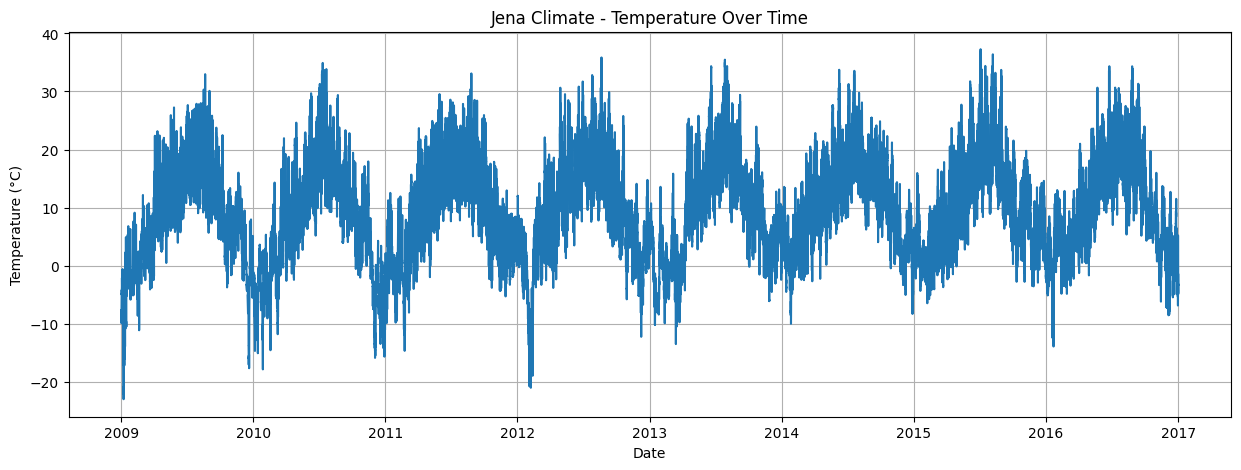

In [3]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["Date Time"],
    df["T (degC)"]
)

plt.title("Jena Climate - Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid()

plt.show()

In [4]:
#reduce data size
df = df.set_index("Date Time")

hourly_df = df.resample("1h").mean()

print("Hourly Dataset Shape:", hourly_df.shape)

hourly_df.head()

Hourly Dataset Shape: (70129, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


In [5]:
#Selecting features
features = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)"
]

data = hourly_df[features].dropna()

print("Final Dataset Shape:", data.shape)

Final Dataset Shape: (70041, 7)


In [6]:
#Train-Test split
train_size = int(len(data) * 0.8)

train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

print("Training Samples:", len(train_data))
print("Testing Samples:", len(test_data))

Training Samples: 56032
Testing Samples: 14009


In [7]:
#Normalize the data
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)

test_scaled = scaler.transform(test_data)

In [8]:
#Create Time Sequences
TIME_STEP = 24

def create_sequences(data, time_step):

    X = []
    y = []

    for i in range(time_step, len(data)):

        X.append(
            data[i-time_step:i]
        )

        # Temperature is column 1
        y.append(
            data[i, 1]
        )

    return np.array(X), np.array(y)

In [9]:
#Generate Training and Testing Sequences
X_train, y_train = create_sequences(
    train_scaled,
    TIME_STEP
)

X_test, y_test = create_sequences(
    test_scaled,
    TIME_STEP
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (56008, 24, 7)
y_train: (56008,)
X_test: (13985, 24, 7)
y_test: (13985,)


In [10]:
#Building LSTM model
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        32,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(
    Dense(16, activation="relu")
)

model.add(
    Dense(1)
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#Complile Model
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

In [13]:
#Train Model
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
876/876 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - loss: 4.0734e-04 - mae: 0.0152 - val_loss: 0.0050 - val_mae: 0.0670
Epoch 2/5
876/876 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 3.4958e-04 - mae: 0.0140 - val_loss: 0.0040 - val_mae: 0.0594
Epoch 3/5
876/876 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - loss: 3.2214e-04 - mae: 0.0134 - val_loss: 0.0034 - val_mae: 0.0539
Epoch 4/5
876/876 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - loss: 2.9700e-04 - mae: 0.0128 - val_loss: 0.0052 - val_mae: 0.0654
Epoch 5/5
876/876 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - loss: 2.8117e-04 - mae: 0.0125 - val_loss: 0.0049 - val_mae: 0.0624


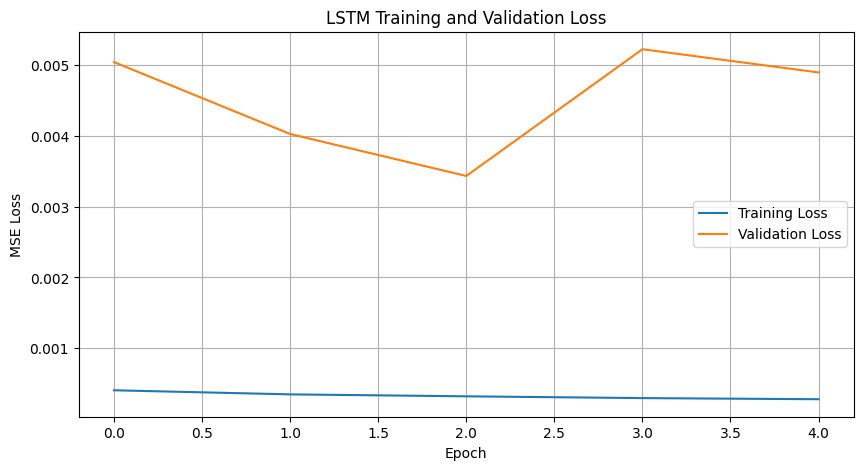

In [14]:
#Plot Training Loss
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid()

plt.show()

In [15]:
#Make Predictions
predicted_scaled = model.predict(X_test)

dummy_pred = np.zeros(
    (len(predicted_scaled), len(features))
)

dummy_actual = np.zeros(
    (len(y_test), len(features))
)

# Temperature is column 1
dummy_pred[:, 1] = predicted_scaled.flatten()
dummy_actual[:, 1] = y_test

predictions = scaler.inverse_transform(
    dummy_pred
)[:, 1]

actual = scaler.inverse_transform(
    dummy_actual
)[:, 1]

438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [16]:
#Calculate Performance
mse = mean_squared_error(
    actual,
    predictions
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    actual,
    predictions
)

r2 = r2_score(
    actual,
    predictions
)

print("=" * 50)
print("LSTM MODEL PERFORMANCE")
print("=" * 50)

print("MSE  :", round(mse, 4))
print("RMSE :", round(rmse, 4))
print("MAE  :", round(mae, 4))
print("R²   :", round(r2, 4))

LSTM MODEL PERFORMANCE
MSE  : 11.6135
RMSE : 3.4079
MAE  : 3.1376
R²   : 0.8228


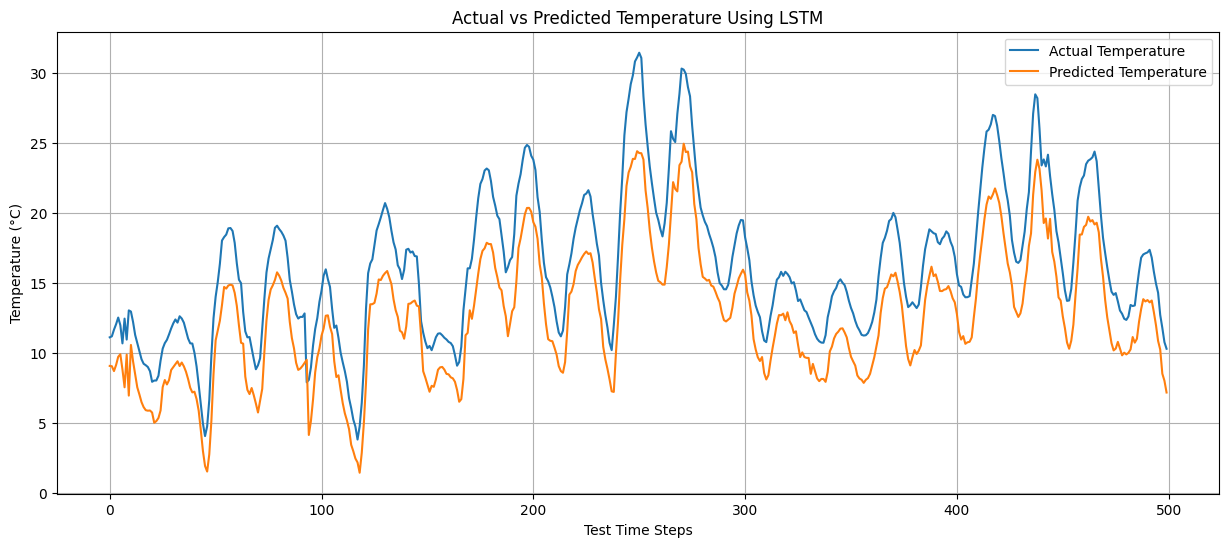

In [17]:
#Actual vs Predicted Temperature
plt.figure(figsize=(15, 6))

plt.plot(
    actual[:500],
    label="Actual Temperature"
)

plt.plot(
    predictions[:500],
    label="Predicted Temperature"
)

plt.title(
    "Actual vs Predicted Temperature Using LSTM"
)

plt.xlabel("Test Time Steps")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid()

plt.show()

In [18]:
#Predict next hour
last_sequence = test_scaled[-TIME_STEP:]

last_sequence = last_sequence.reshape(
    1,
    TIME_STEP,
    len(features)
)

next_temperature_scaled = model.predict(
    last_sequence
)

dummy = np.zeros(
    (1, len(features))
)

dummy[0, 1] = next_temperature_scaled[0][0]

next_temperature = scaler.inverse_transform(
    dummy
)[0, 1]

print(
    "Predicted Temperature for Next Hour:",
    round(next_temperature, 2),
    "°C"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Temperature for Next Hour: -6.71 °C
